In [2]:
import csv
import os
import math

import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def read_csv(file_path):
  X1 = []
  X2 = []
  y = []

  with open(file_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)

    for row in reader:
      X1.append(float(row[0]))
      X2.append(float(row[1]))
      y.append(float(row[2]))

  return X1, X2, y

In [4]:
def sigmoid(z):
  if z < -100:
    return 0.0
  if z > 100:
    return 1.0

  return 1 / (1 + math.exp(-z))


def loss(X1, X2, y, w0, w1, w2):
  n = len(y)
  total = 0.0

  for i in range(n):
    z = w0 + w1 * X1[i] + w2 * X2[i]
    y_pred = sigmoid(z)

    if y_pred < 1e-10:
      y_pred = 1e-10
    if y_pred > 0.9999999999:
      y_pred = 0.9999999999

    total += -(y[i] * math.log(y_pred) + (1 - y[i]) * math.log(1 - y_pred))

  return total / n

In [5]:
def compute_gradients(X1, X2, y, w0, w1, w2):
  n = len(y)

  dw0 = 0.0
  dw1 = 0.0
  dw2 = 0.0

  for i in range(n):
    z = w0 + w1 * X1[i] + w2 * X2[i]
    y_pred = sigmoid(z)
    error = y_pred - y[i]

    dw0 += error
    dw1 += error * X1[i]
    dw2 += error * X2[i]

  dw0 = dw0 / n
  dw1 = dw1 / n
  dw2 = dw2 / n

  return dw0, dw1, dw2


def gradient_descent(X1, X2, y, lr, Time, show=True):
  w0 = 0.0
  w1 = 0.0
  w2 = 0.0

  history = []

  for times in range(1, Time + 1):
    dw0, dw1, dw2 = compute_gradients(X1, X2, y, w0, w1, w2)

    w0 = w0 - lr * dw0
    w1 = w1 - lr * dw1
    w2 = w2 - lr * dw2

    current_loss = loss(X1, X2, y, w0, w1, w2)
    history.append([times, w0, w1, w2, current_loss])

    if show == True:
      if times <= 10 or times % 1000 == 0:
        print(f"Time {times}: w0 = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}, loss = {current_loss:.6f}")

    if current_loss > 1000:
      break

  return w0, w1, w2, history

In [6]:
def predict_one(x1, x2, w0, w1, w2):
  z = w0 + w1 * x1 + w2 * x2
  probability = sigmoid(z)

  if probability >= 0.5:
    return 1, probability

  return 0, probability


def accuracy(X1, X2, y, w0, w1, w2):
  correct = 0

  for i in range(len(y)):
    y_pred, probability = predict_one(X1[i], X2[i], w0, w1, w2)

    if y_pred == int(y[i]):
      correct += 1

  return correct / len(y)

In [7]:
file_path = 'loan2.csv'

if os.path.exists(file_path) == False:
  file_path = '/content/drive/MyDrive/DATA/DL/loan2.csv'

X1, X2, y = read_csv(file_path)

print('Experience =', X1)
print('Salary =', X2)
print('Loan =', y)

Experience = [3.0, 2.5, 1.0, 2.5, 2.0, 1.5, 0.5, 1.75, 0.25, 1.0, 0.25, 0.2, 0.15, 2.0, 1.0, 0.15, 0.1, 0.5, 1.0]
Salary = [4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 5.0, 6.0, 6.0, 7.0, 7.0, 7.0, 7.0, 8.0, 8.0, 8.0, 8.0, 9.0, 10.0]
Loan = [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0]


In [8]:
w0, w1, w2, history = gradient_descent(X1, X2, y, lr=0.1, Time=10000)

print('Final result:')
print(f'w0 = {w0:.6f}')
print(f'w1 = {w1:.6f}')
print(f'w2 = {w2:.6f}')
print(f'loss = {history[-1][4]:.6f}')
print(f'accuracy = {accuracy(X1, X2, y, w0, w1, w2):.4f}')

Time 1: w0 = -0.0026, w1 = 0.0293, w2 = -0.0184, loss = 0.682391
Time 2: w0 = -0.0030, w1 = 0.0602, w2 = -0.0205, loss = 0.672996
Time 3: w0 = -0.0040, w1 = 0.0898, w2 = -0.0251, loss = 0.664144
Time 4: w0 = -0.0050, w1 = 0.1186, w2 = -0.0292, loss = 0.655780
Time 5: w0 = -0.0061, w1 = 0.1466, w2 = -0.0332, loss = 0.647875
Time 6: w0 = -0.0073, w1 = 0.1738, w2 = -0.0370, loss = 0.640402
Time 7: w0 = -0.0087, w1 = 0.2003, w2 = -0.0407, loss = 0.633333
Time 8: w0 = -0.0101, w1 = 0.2261, w2 = -0.0443, loss = 0.626643
Time 9: w0 = -0.0117, w1 = 0.2511, w2 = -0.0478, loss = 0.620309
Time 10: w0 = -0.0133, w1 = 0.2755, w2 = -0.0511, loss = 0.614309
Time 1000: w0 = -3.6258, w1 = 2.2566, w2 = 0.1947, loss = 0.331319
Time 2000: w0 = -5.8674, w1 = 2.7423, w2 = 0.4443, loss = 0.277204
Time 3000: w0 = -7.3930, w1 = 3.0857, w2 = 0.6118, loss = 0.252260
Time 4000: w0 = -8.5402, w1 = 3.3482, w2 = 0.7367, loss = 0.238183
Time 5000: w0 = -9.4563, w1 = 3.5603, w2 = 0.8360, loss = 0.229213
Time 6000: w0 

In [9]:
for i in range(len(y)):
  y_pred, probability = predict_one(X1[i], X2[i], w0, w1, w2)
  print(f"x1 = {X1[i]}, x2 = {X2[i]}, real = {int(y[i])}, probability = {probability:.4f}, predict = {y_pred}")

x1 = 3.0, x2 = 4.0, real = 1, probability = 0.9931, predict = 1
x1 = 2.5, x2 = 4.0, real = 1, probability = 0.9451, predict = 1
x1 = 1.0, x2 = 4.0, real = 0, probability = 0.0285, predict = 0
x1 = 2.5, x2 = 5.0, real = 1, probability = 0.9819, predict = 1
x1 = 2.0, x2 = 5.0, real = 1, probability = 0.8664, predict = 1
x1 = 1.5, x2 = 5.0, real = 0, probability = 0.4367, predict = 0
x1 = 0.5, x2 = 5.0, real = 0, probability = 0.0109, predict = 0
x1 = 1.75, x2 = 6.0, real = 1, probability = 0.8760, predict = 1
x1 = 0.25, x2 = 6.0, real = 0, probability = 0.0119, predict = 0
x1 = 1.0, x2 = 7.0, real = 1, probability = 0.4791, predict = 0
x1 = 0.25, x2 = 7.0, real = 0, probability = 0.0366, predict = 0
x1 = 0.2, x2 = 7.0, real = 0, probability = 0.0298, predict = 0
x1 = 0.15, x2 = 7.0, real = 0, probability = 0.0242, predict = 0
x1 = 2.0, x2 = 8.0, real = 1, probability = 0.9951, predict = 1
x1 = 1.0, x2 = 8.0, real = 0, probability = 0.7435, predict = 1
x1 = 0.15, x2 = 8.0, real = 0, proba

In [10]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

for r in learning_rates:
  w0_temp, w1_temp, w2_temp, history_temp = gradient_descent(X1, X2, y, lr=r, Time=10000, show=False)

  final_loss = history_temp[-1][4]
  final_acc = accuracy(X1, X2, y, w0_temp, w1_temp, w2_temp)

  print(f'r = {r}: w0 = {w0_temp:.4f}, w1 = {w1_temp:.4f}, w2 = {w2_temp:.4f}, loss = {final_loss:.4f}, accuracy = {final_acc:.4f}')

r = 0.001: w0 = -0.3310, w1 = 1.2495, w2 = -0.1400, loss = 0.4734, accuracy = 0.7368
r = 0.01: w0 = -3.6249, w1 = 2.2565, w2 = 0.1946, loss = 0.3313, accuracy = 0.7895
r = 0.1: w0 = -12.3682, w1 = 4.2492, w2 = 1.1479, loss = 0.2104, accuracy = 0.8947
r = 1.0: w0 = -28.6238, w1 = 8.5510, w2 = 3.1459, loss = 0.3233, accuracy = 0.9474


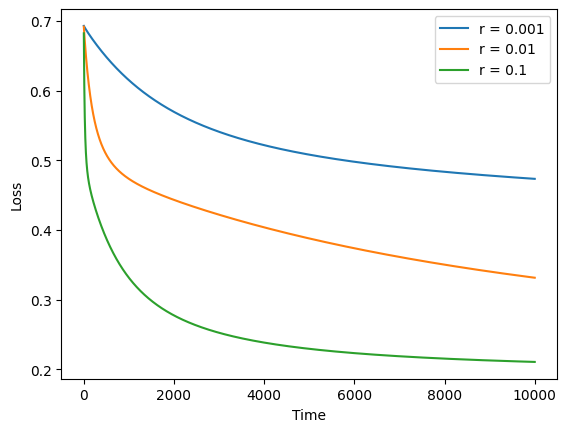

In [11]:
for r in [0.001, 0.01, 0.1]:
  w0_temp, w1_temp, w2_temp, history_temp = gradient_descent(X1, X2, y, lr=r, Time=10000, show=False)

  times = []
  losses = []

  for item in history_temp:
    times.append(item[0])
    losses.append(item[4])

  plt.plot(times, losses, label='r = ' + str(r))

plt.xlabel('Time')
plt.ylabel('Loss')
plt.legend()
plt.show()